In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import copy
import os

from torch.utils.data import TensorDataset, DataLoader

In [2]:
# directly copied from the first class
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
    device = torch.device("cuda")
    !nvidia-smi
else:
    device = torch.device("cpu")

print("Selected device:", device)

PyTorch version: 2.7.0
CUDA available: False
Selected device: cpu


In [3]:
 # L-BFGS
# data loading and presenting
orbits = ['ORB04', "ORB11", "ORB12", "ORB14", "ORB19", "ORB26"]
orbits = ['ORB04', "ORB14", "ORB19"]

savefiles_prefix = "SiLU_end_Tanh"
folder_name = "SiLU_end_Tanh"


try:
    os.mkdir(folder_name)
except:
    print("File already exists")


orbits_preproc_data = []


for i, orbit in enumerate(orbits):
    str = f"{orbits[i]}_EUR_EPHIO.csv"
    current_orbit_data = []
    df = pd.read_csv(str)

    # input X, Y, Z coordinates
    X_raw = df[['X', 'Y', 'Z']].values
    # output Magnetic Field Bx, By, Bz
    y_raw = df[['BX', 'BY', 'BZ']].values

    # scales data  to [-1, 1] for Tanh or sigmoid
    input_scaler = MinMaxScaler(feature_range=(-1, 1))
    output_scaler = MinMaxScaler(feature_range=(-1, 1))

    X_scaled = input_scaler.fit_transform(X_raw)
    y_scaled = output_scaler.fit_transform(y_raw)

    # to tensor
    X_tensor = torch.tensor(X_scaled, dtype=torch.float32).to(device) # Cuda czyni cuda
    y_tensor = torch.tensor(y_scaled, dtype=torch.float32).to(device) # tu też

    # data split
    X_train, X_val, y_train, y_val = train_test_split(X_tensor, y_tensor, test_size=0.2, random_state=67)

    current_orbit_data.append((X_raw, y_raw, X_train, y_train, X_val, y_val, input_scaler, output_scaler))
    orbits_preproc_data.append(current_orbit_data)


File already exists


In [4]:

# define the model
class PINN(nn.Module):
    def __init__(self):
        super(PINN, self).__init__()
        # Standard MLP architecture
        self.net = nn.Sequential(
            nn.Linear(3, 64),
            nn.SiLU(),
            nn.Linear(64, 128),
            nn.SiLU(),
            nn.Linear(128, 128),
            nn.SiLU(),
            nn.Linear(128, 128),
            nn.SiLU(),
            nn.Linear(128, 128),
            nn.SiLU(),
            nn.Linear(128, 64),
            nn.Tanh(),
            nn.Linear(64, 3)  # Output: Bx, By, Bz
        )

    def forward(self, x):
        return self.net(x)


In [5]:
def physics_loss_function(model, x_collocation):
  # gradient tracking
  x_collocation.requires_grad = True

  # predicts B-field
  b_pred = model(x_collocation)

  # separates components
  bx = b_pred[:, 0].unsqueeze(1)
  by = b_pred[:, 1].unsqueeze(1)
  bz = b_pred[:, 2].unsqueeze(1)

  # calculates gradients (d(Bi)/dxj)
  grads_bx = torch.autograd.grad(bx, x_collocation, grad_outputs=torch.ones_like(bx), create_graph=True)[0]
  dbx_dx, dbx_dy, dbx_dz = grads_bx[:, 0], grads_bx[:, 1], grads_bx[:, 2]

  grads_by = torch.autograd.grad(by, x_collocation, grad_outputs=torch.ones_like(by), create_graph=True)[0]
  dby_dx, dby_dy, dby_dz = grads_by[:, 0], grads_by[:, 1], grads_by[:, 2]

  grads_bz = torch.autograd.grad(bz, x_collocation, grad_outputs=torch.ones_like(bz), create_graph=True)[0]
  dbz_dx, dbz_dy, dbz_dz = grads_bz[:, 0], grads_bz[:, 1], grads_bz[:, 2]


  # first term - Gauss's law for magnetism div(B) = 0 -> divergence free -> no monopoles
  divergence = dbx_dx + dby_dy + dbz_dz
  loss_div = torch.mean(divergence**2)

  # second term - Ampere's law curl(B) = 0 -> irrotational -> current free
  curl_x = dbz_dy - dby_dz
  curl_y = dbx_dz - dbz_dx
  curl_z = dby_dx - dbx_dy
  loss_curl = torch.mean(curl_x**2 + curl_y**2 + curl_z**2)

  return loss_div + loss_curl
  ###################################

# function that generates random collocation points
def get_collocation_points(n_points=2000, bounds=(-1, 1), device=device):
  points = (bounds[1] - bounds[0] * torch.rand(n_points, 3, device=device) + bounds[0])
  return points.to(device)

In [6]:
epochs = 500
batch_size = 512
lambda_physics = 0.5

no_collocation_points = 3000

# current_orbit_data.append((X_raw, y_raw, X_train, y_train, X_val, y_val, input_scaler, output_scaler))
orbits_models_data = []

for i, orbit_data in enumerate(orbits_preproc_data):
  model = PINN().to(device)
  optimizer = optim.Adam(model.parameters(), lr=1e-3)
  criterion_data = nn.MSELoss()

  print(f"Training on orbit: {orbits[i]}")

  X_train, y_train = orbit_data[0][2], orbit_data[0][3]

  train_dataset = TensorDataset(X_train, y_train)

  train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)


  loss_history = {'data': [], 'physics': []}

  for epoch in range(epochs):
    model.train()

    epoch_data_loss = 0.0
    epoch_physics_loss = 0.0

    for batch_X, batch_y in train_loader:

      optimizer.zero_grad()

      # data loss
      pred_data = model(batch_X)
      loss_data = criterion_data(pred_data, batch_y)

      # physics loss
      x_phys = get_collocation_points(n_points=no_collocation_points, device=device)
      loss_physics = physics_loss_function(model, x_phys)

      loss_total = loss_data + lambda_physics * loss_physics

      loss_total.backward()
      optimizer.step()

      epoch_data_loss += loss_data.item()
      epoch_physics_loss += loss_physics.item()

    avg_data_loss = epoch_data_loss / len(train_loader)
    avg_physics_loss = epoch_physics_loss / len(train_loader)

    loss_history['data'].append(avg_data_loss)
    loss_history['physics'].append(avg_physics_loss)

    if (epoch + 1) % (epochs/10) == 0:
      print(f"Orbit: {orbits[i]} | Epoch {epoch + 1}/{epochs} | Data Loss: {avg_data_loss:.5f} | Physics Loss: {avg_physics_loss:.5f}")

  # orbits_models_data.append((model.state_dict(), loss_history))
  orbits_models_data.append((copy.deepcopy(model.state_dict()), loss_history))

Training on orbit: ORB04
Orbit: ORB04 | Epoch 50/500 | Data Loss: 0.00670 | Physics Loss: 0.00039
Orbit: ORB04 | Epoch 100/500 | Data Loss: 0.00607 | Physics Loss: 0.00034
Orbit: ORB04 | Epoch 150/500 | Data Loss: 0.00481 | Physics Loss: 0.00047
Orbit: ORB04 | Epoch 200/500 | Data Loss: 0.00409 | Physics Loss: 0.00029
Orbit: ORB04 | Epoch 250/500 | Data Loss: 0.00386 | Physics Loss: 0.00006
Orbit: ORB04 | Epoch 300/500 | Data Loss: 0.00468 | Physics Loss: 0.00017
Orbit: ORB04 | Epoch 350/500 | Data Loss: 0.00393 | Physics Loss: 0.00018
Orbit: ORB04 | Epoch 400/500 | Data Loss: 0.00374 | Physics Loss: 0.00007
Orbit: ORB04 | Epoch 450/500 | Data Loss: 0.00368 | Physics Loss: 0.00005
Orbit: ORB04 | Epoch 500/500 | Data Loss: 0.00636 | Physics Loss: 0.00267
Training on orbit: ORB14
Orbit: ORB14 | Epoch 50/500 | Data Loss: 0.00278 | Physics Loss: 0.00101
Orbit: ORB14 | Epoch 100/500 | Data Loss: 0.00245 | Physics Loss: 0.00025
Orbit: ORB14 | Epoch 150/500 | Data Loss: 0.00241 | Physics Loss

KeyboardInterrupt: 

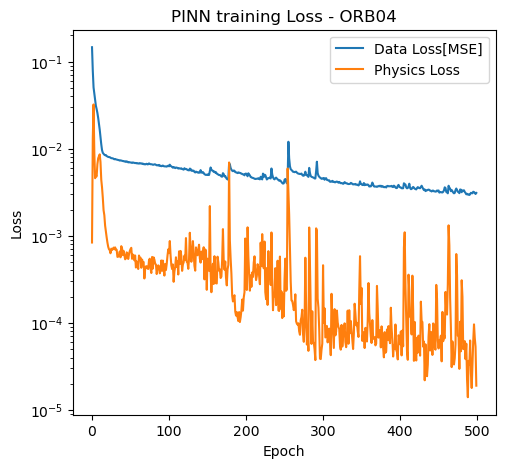

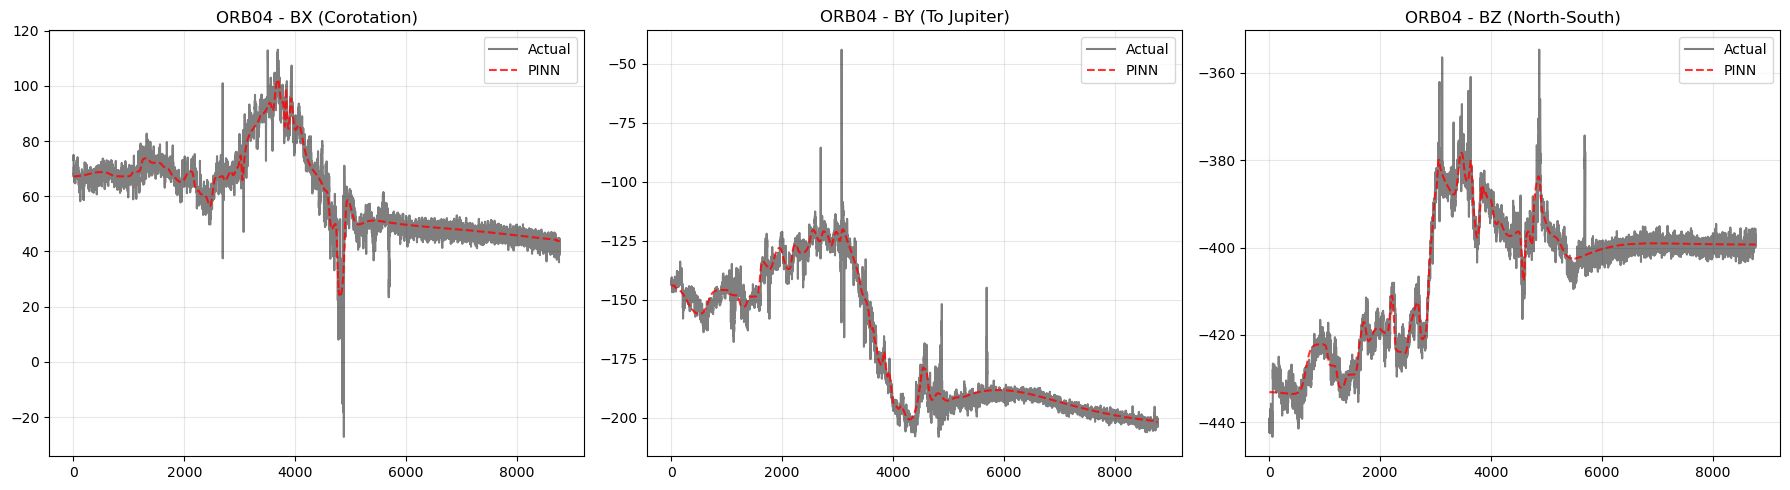

PINN Model for ORB04 saved.


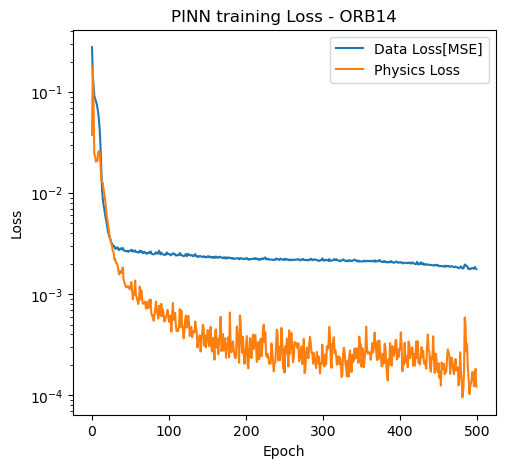

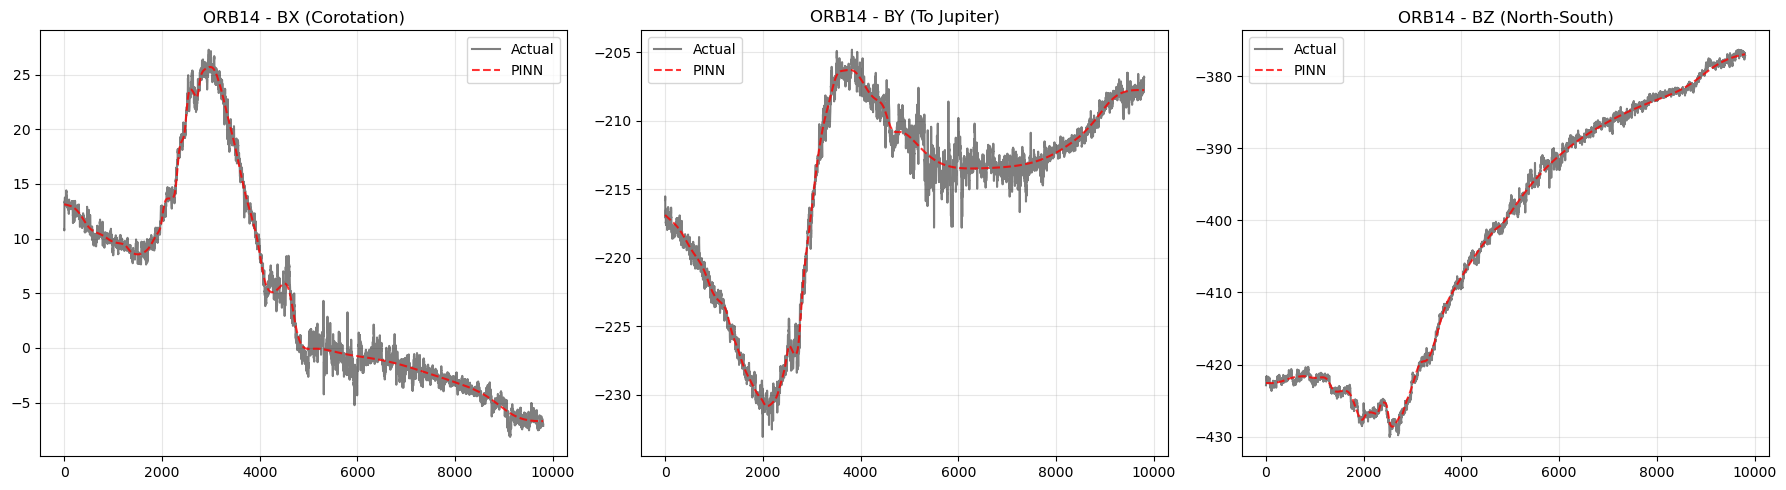

PINN Model for ORB14 saved.


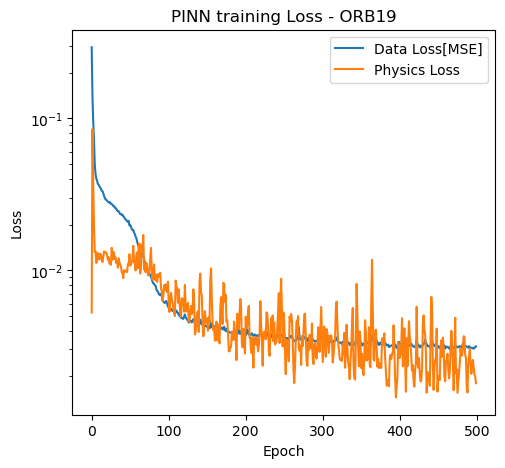

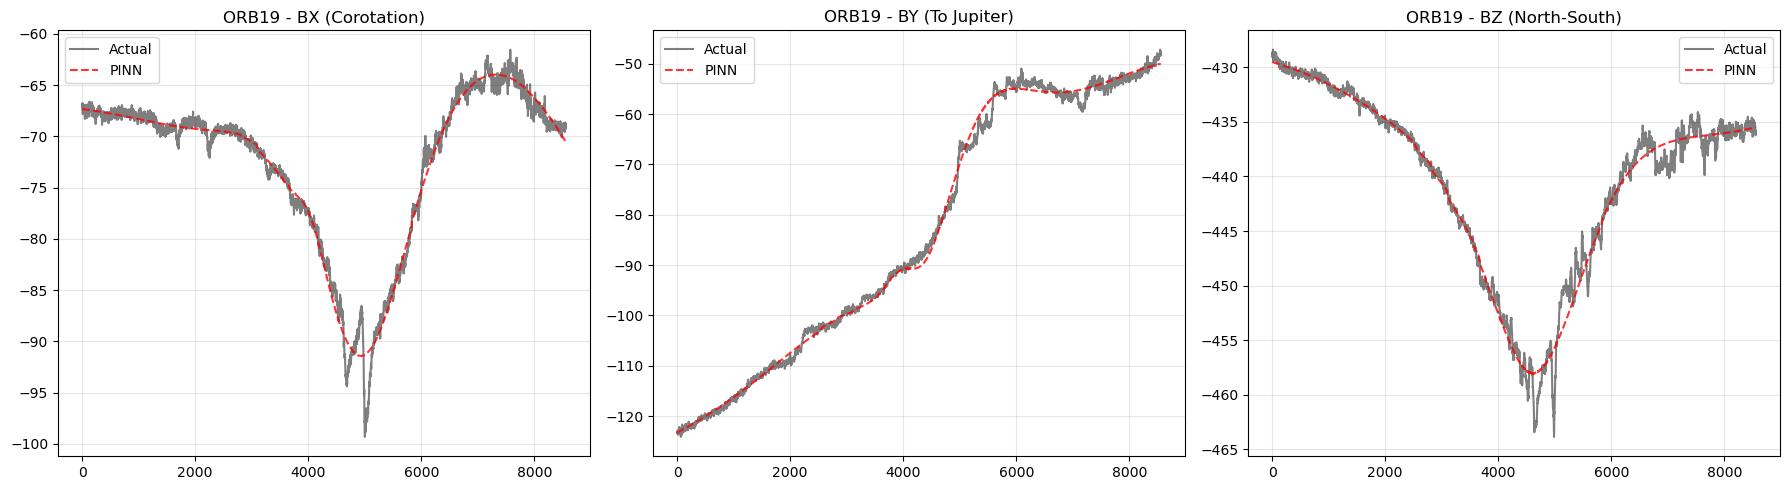

PINN Model for ORB19 saved.


In [ ]:
for i, (orbit_packet, model_packet) in enumerate(zip(orbits_preproc_data, orbits_models_data)):

  data_tuple = orbit_packet[0]
  X_raw, y_raw, X_train, y_train, X_val, y_val, input_scaler, output_scaler = data_tuple

  model_state, loss_history = model_packet

  model = PINN().to(device)
  model.load_state_dict(model_state)
  model.eval()

  plt.figure(figsize=(12, 5))

  #loss plot
  plt.subplot(1, 2, 1)
  plt.plot(loss_history['data'], label='Data Loss[MSE]')
  plt.plot(loss_history['physics'], label='Physics Loss')
  plt.yscale('log')
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.title(f'PINN training Loss - {orbits[i]}')
  plt.legend()

  # prediction plot

  with torch.no_grad():
    X_scaled_current = input_scaler.transform(X_raw)
    X_tensor_current = torch.tensor(X_scaled_current, dtype=torch.float32).to(device)

    full_pred_scaled = model(X_tensor_current)
    full_pred = output_scaler.inverse_transform(full_pred_scaled.cpu().numpy()) # had to move it back to cpu before numpy or scikit-learn (it cried otherwise)


    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    components = ['BX (Corotation)', 'BY (To Jupiter)', 'BZ (North-South)']

    for k in range(3):
        axes[k].plot(y_raw[:, k], 'k-', alpha=0.5, label='Actual')
        axes[k].plot(full_pred[:, k], 'r--', alpha=0.8, label='PINN')
        axes[k].set_title(f'{orbits[i]} - {components[k]}')
        axes[k].legend()
        axes[k].grid(True, alpha=0.3)

    plt.tight_layout()
    # plt.savefig(f'pinn_results_{orbits[i]}_3components.png')
    plt.savefig(f'{folder_name}/{savefiles_prefix}_{orbits[i]}_3components.png')
    plt.show()

  # Save model
  torch.save(model.state_dict(), f'{folder_name}/europa_pinn_model_{orbits[i]}.pth')
  print(f"PINN Model for {orbits[i]} saved.")



In [ ]:


# for i, (orbit_packet, model_packet) in enumerate(zip(orbits_preproc_data, orbits_models_data)):

#     model = PINN()

#     data_tuple = orbit_packet[0]
#     X_raw, y_raw, X_train, y_train, X_val, y_val, input_scaler, output_scaler = data_tuple

#     model_state, loss_history = model_packet

#     model.load_state_dict(model_state)

#     model.eval()
#     with torch.no_grad():
#         X_scaled_current = input_scaler.transform(X_raw)
#         X_tensor_current = torch.tensor(X_scaled_current, dtype=torch.float32)

#         full_pred_scaled = model(X_tensor_current)
#         full_pred = output_scaler.inverse_transform(full_pred_scaled.numpy())

#     fig, axes = plt.subplots(1, 3, figsize=(18, 5))

#     components = ['BX (Corotation)', 'BY (To Jupiter)', 'BZ (North-South)']

#     for k in range(3):
#         axes[k].plot(y_raw[:, k], 'k-', alpha=0.5, label='Actual')      # Black = Data
#         axes[k].plot(full_pred[:, k], 'r--', alpha=0.8, label='PINN')   # Red = Model
#         axes[k].set_title(f'{orbits[i]} - {components[k]}')
#         axes[k].legend()
#         axes[k].grid(True, alpha=0.3)

#     plt.tight_layout()
#     plt.savefig(f'pinn_results_{orbits[i]}_3components.png')
#     plt.show()

#     # Save model
#     torch.save(model.state_dict(), f'europa_pinn_model_{orbits[i]}.pth')
#     print(f"PINN Model for {orbits[i]} saved.")

